# IPL Data Analysis Using Python (2008–2025)

## Objective

The objective of this project is to analyze IPL match data using Python 
to generate insights about team performance, player statistics, scoring trends, 
and match outcomes using data analysis and visualization techniques.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
plt.style.use("ggplot")

## Data Loading

In [9]:
import os
os.getcwd()

'C:\\Users\\gk413'

In [17]:
teams.shape
team_performance.shape
players.shape
ball_by_ball.shape

(255759, 19)

In [19]:
ball_by_ball.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255759 entries, 0 to 255758
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Match id             255759 non-null  int64  
 1   Date                 255759 non-null  object 
 2   Season               255759 non-null  object 
 3   Batting team         255759 non-null  object 
 4   Bowling team         255759 non-null  object 
 5   Innings No           255759 non-null  int64  
 6   Ball No              255759 non-null  float64
 7   Bowler               255759 non-null  object 
 8   Striker              255759 non-null  object 
 9   Non Striker          255759 non-null  object 
 10  runs_scored          255759 non-null  int64  
 11  extras               255759 non-null  int64  
 12  type of extras       13823 non-null   object 
 13  score                255759 non-null  int64  
 14  score/wicket         255759 non-null  object 
 15  wicket_confirmati

In [21]:
ball_by_ball.isnull().sum()

Match id                    0
Date                        0
Season                      0
Batting team                0
Bowling team                0
Innings No                  0
Ball No                     0
Bowler                      0
Striker                     0
Non Striker                 0
runs_scored                 0
extras                      0
type of extras         241936
score                       0
score/wicket                0
wicket_confirmation         0
wicket_type            243108
fielders_involved      246637
Player Out             243108
dtype: int64

In [23]:
ball_by_ball["type of extras"] = ball_by_ball["type of extras"].fillna("None")

ball_by_ball["wicket_type"] = ball_by_ball["wicket_type"].fillna("No Wicket")

ball_by_ball["fielders_involved"] = ball_by_ball["fielders_involved"].fillna("None")

ball_by_ball["Player Out"] = ball_by_ball["Player Out"].fillna("Not Out")

In [25]:
ball_by_ball.isnull().sum()

Match id               0
Date                   0
Season                 0
Batting team           0
Bowling team           0
Innings No             0
Ball No                0
Bowler                 0
Striker                0
Non Striker            0
runs_scored            0
extras                 0
type of extras         0
score                  0
score/wicket           0
wicket_confirmation    0
wicket_type            0
fielders_involved      0
Player Out             0
dtype: int64

In [27]:
top_batsmen = (
    ball_by_ball
    .groupby("Striker")["runs_scored"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_batsmen

Striker
V Kohli           7773
S Dhawan          6769
DA Warner         6566
RG Sharma         6528
SK Raina          5536
MS Dhoni          5192
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4779
Name: runs_scored, dtype: int64

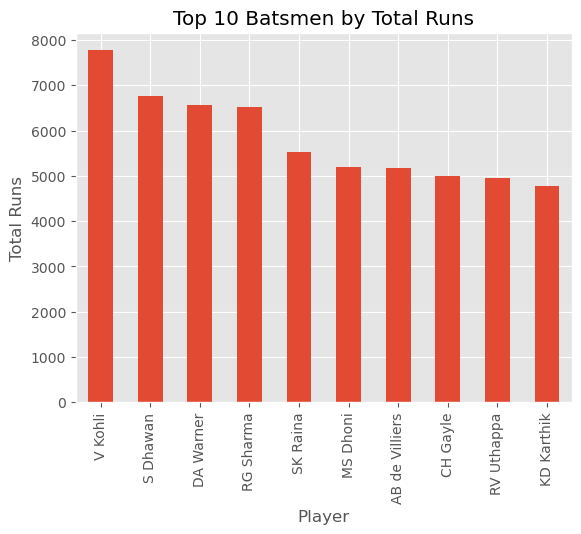

In [29]:
top_batsmen.plot(kind="bar")

plt.title("Top 10 Batsmen by Total Runs")
plt.xlabel("Player")
plt.ylabel("Total Runs")

plt.show()

Insight:

The visualization shows the top 10 batsmen with the highest total runs in IPL history.
The leading players have consistently performed across multiple seasons,
demonstrating strong batting performance and reliability.
This insight helps identify key performers who contribute significantly to team success.

In [32]:
top_bowlers = (
    ball_by_ball[ball_by_ball["wicket_confirmation"] == 1]
    .groupby("Bowler")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_bowlers

Bowler
YS Chahal     208
DJ Bravo      207
SP Narine     193
PP Chawla     192
R Ashwin      191
B Kumar       189
SL Malinga    188
A Mishra      183
JJ Bumrah     175
RA Jadeja     166
dtype: int64

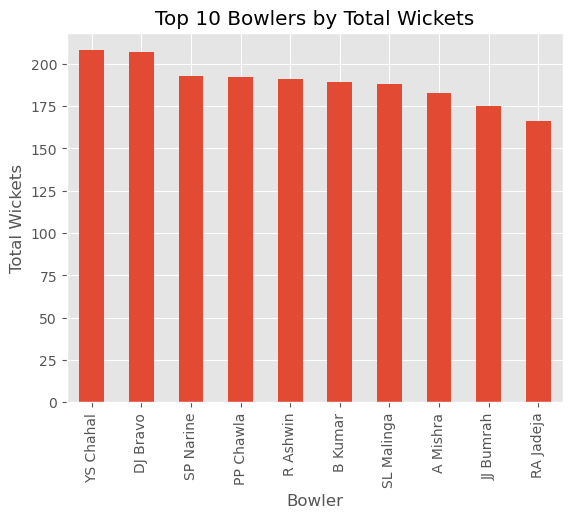

In [34]:
top_bowlers.plot(kind="bar")

plt.title("Top 10 Bowlers by Total Wickets")
plt.xlabel("Bowler")
plt.ylabel("Total Wickets")

plt.show()

Insight:

The chart highlights the top 10 bowlers with the highest number of wickets in IPL history.
These bowlers play a crucial role in controlling matches and reducing opponent scoring,
making them valuable assets to their teams.

In [37]:
top_bowlers

Bowler
YS Chahal     208
DJ Bravo      207
SP Narine     193
PP Chawla     192
R Ashwin      191
B Kumar       189
SL Malinga    188
A Mishra      183
JJ Bumrah     175
RA Jadeja     166
dtype: int64

Insight:

The visualization shows the top 10 bowlers with the highest number of wickets in IPL history.
These bowlers consistently contribute to match outcomes by taking crucial wickets,
demonstrating strong bowling performance and reliability across seasons.

In [44]:
ball_by_ball["Date"] = pd.to_datetime(ball_by_ball["Date"])

ball_by_ball["Year"] = ball_by_ball["Date"].dt.year

In [42]:
Year

NameError: name 'Year' is not defined

In [46]:
ball_by_ball.head()

,Match id,Date,Season,Batting team,Bowling team,Innings No,Ball No,Bowler,Striker,Non Striker,runs_scored,extras,type of extras,score,score/wicket,wicket_confirmation,wicket_type,fielders_involved,Player Out,Year
0,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.1,P Kumar,SC Ganguly,BB McCullum,0,1,legbyes,1,1/0,0,No Wicket,None,Not Out,2008
1,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.2,P Kumar,BB McCullum,SC Ganguly,0,0,None,1,1/0,0,No Wicket,None,Not Out,2008
2,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.2,P Kumar,BB McCullum,SC Ganguly,0,1,wides,2,2/0,0,No Wicket,None,Not Out,2008
3,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.3,P Kumar,BB McCullum,SC Ganguly,0,0,None,2,2/0,0,No Wicket,None,Not Out,2008
4,335982,2008-04-18,2007/08,Kolkata Knight Riders,Royal Challengers Bangalore,1,0.4,P Kumar,BB McCullum,SC Ganguly,0,0,None,2,2/0,0,No Wicket,None,Not Out,2008


In [48]:
ball_by_ball.columns

Index(['Match id', 'Date', 'Season', 'Batting team', 'Bowling team',
       'Innings No', 'Ball No', 'Bowler', 'Striker', 'Non Striker',
       'runs_scored', 'extras', 'type of extras', 'score', 'score/wicket',
       'wicket_confirmation', 'wicket_type', 'fielders_involved', 'Player Out',
       'Year'],
      dtype='object')

In [50]:
matches_per_year = (
    ball_by_ball
    .groupby("Year")["Match id"]
    .nunique()
)

matches_per_year

Year
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2020    60
2021    60
2022    74
2023    74
2024    49
Name: Match id, dtype: int64

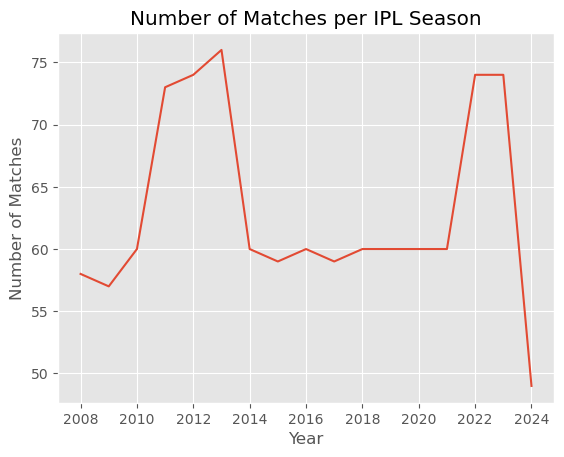

In [52]:
matches_per_year.plot(kind="line")

plt.title("Number of Matches per IPL Season")
plt.xlabel("Year")
plt.ylabel("Number of Matches")

plt.show()

Insight:

The line chart shows the number of matches played in each IPL season.
The gradual increase in matches indicates the expansion and growing popularity
of the IPL tournament over time.

In [55]:
matches_per_year

Year
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2020    60
2021    60
2022    74
2023    74
2024    49
Name: Match id, dtype: int64

In [57]:
runs_per_year = (
    ball_by_ball
    .groupby("Year")["runs_scored"]
    .sum()
)

runs_per_year

Year
2008    16809
2009    15376
2010    17754
2011    19928
2012    21323
2013    21487
2014    17943
2015    17427
2016    17962
2017    17920
2018    19098
2019    18607
2020    18566
2021    17727
2022    23052
2023    24428
2024    17329
Name: runs_scored, dtype: int64

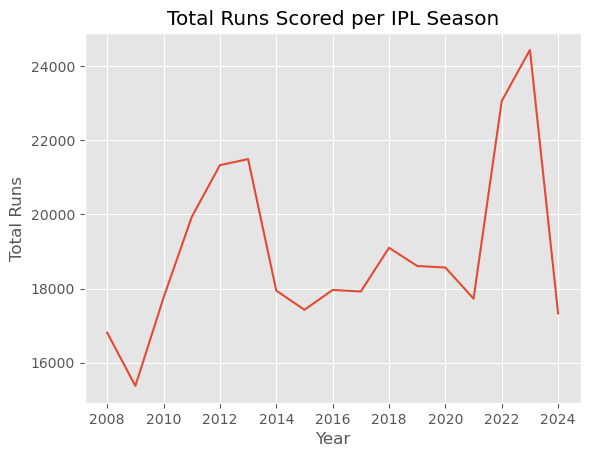

In [59]:
runs_per_year.plot(kind="line")

plt.title("Total Runs Scored per IPL Season")
plt.xlabel("Year")
plt.ylabel("Total Runs")

plt.show()

Insight:

The line chart shows the total runs scored in each IPL season.
An increasing trend in total runs indicates higher scoring matches
and evolving batting strategies over time.

In [62]:
runs_per_year

Year
2008    16809
2009    15376
2010    17754
2011    19928
2012    21323
2013    21487
2014    17943
2015    17427
2016    17962
2017    17920
2018    19098
2019    18607
2020    18566
2021    17727
2022    23052
2023    24428
2024    17329
Name: runs_scored, dtype: int64

In [64]:
team_performance.columns

Index(['Match_ID', 'Date', 'Teams', 'Venue', 'Toss_Winner', 'Toss_Decision',
       'Match_Winner', 'Win_Type', 'Win_Margin', 'First_Innings_Score',
       'Second_Innings_Score', 'Player_of_Match', 'Umpire', 'Umpire1',
       'Umpire2', 'Powerplay_Scores', 'Middle_Overs_Scores',
       'Death_Overs_Scores'],
      dtype='object')

In [68]:
team_performance.columns

Index(['Match_ID', 'Date', 'Teams', 'Venue', 'Toss_Winner', 'Toss_Decision',
       'Match_Winner', 'Win_Type', 'Win_Margin', 'First_Innings_Score',
       'Second_Innings_Score', 'Player_of_Match', 'Umpire', 'Umpire1',
       'Umpire2', 'Powerplay_Scores', 'Middle_Overs_Scores',
       'Death_Overs_Scores'],
      dtype='object')

In [70]:
matches_by_team = (
    team_performance
    .groupby("Teams")["Match_ID"]
    .count()
    .sort_values(ascending=False)
)

matches_by_team

Teams
Chennai Super Kings vs Mumbai Indians                   22
Royal Challengers Bangalore vs Mumbai Indians           19
Royal Challengers Bangalore vs Kolkata Knight Riders    19
Royal Challengers Bangalore vs Chennai Super Kings      18
Mumbai Indians vs Rajasthan Royals                      17
                                                        ..
Rising Pune Supergiant vs Kolkata Knight Riders          1
Rising Pune Supergiant vs Kings XI Punjab                1
Rising Pune Supergiant vs Gujarat Lions                  1
Rising Pune Supergiant vs Delhi Daredevils               1
Sunrisers Hyderabad vs Royal Challengers Bengaluru       1
Name: Match_ID, Length: 211, dtype: int64

In [74]:
top_matches_by_team = (
    team_performance
    .groupby("Teams")["Match_ID"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

top_matches_by_team

Teams
Chennai Super Kings vs Mumbai Indians                   22
Royal Challengers Bangalore vs Mumbai Indians           19
Royal Challengers Bangalore vs Kolkata Knight Riders    19
Royal Challengers Bangalore vs Chennai Super Kings      18
Mumbai Indians vs Rajasthan Royals                      17
Chennai Super Kings vs Rajasthan Royals                 17
Kolkata Knight Riders vs Mumbai Indians                 16
Kolkata Knight Riders vs Rajasthan Royals               16
Mumbai Indians vs Kolkata Knight Riders                 16
Kolkata Knight Riders vs Kings XI Punjab                15
Name: Match_ID, dtype: int64

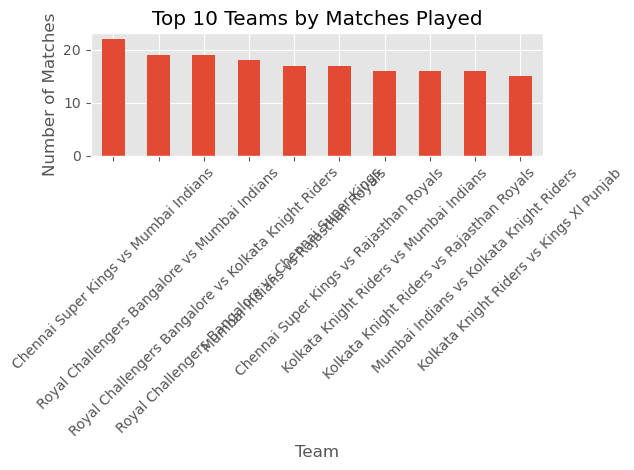

In [76]:
top_matches_by_team.plot(kind="bar")

plt.title("Top 10 Teams by Matches Played")
plt.xlabel("Team")
plt.ylabel("Number of Matches")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Insight:

The chart shows the top 10 IPL teams with the highest number of matches played.
Teams with higher match counts demonstrate consistent participation
and long-term presence in the IPL tournament.

In [79]:
wins_by_team = (
    team_performance
    .groupby("Match_Winner")["Match_ID"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

wins_by_team

Match_Winner
Mumbai Indians                 141
Chennai Super Kings            136
Kolkata Knight Riders          125
Royal Challengers Bangalore    114
Rajasthan Royals               109
Kings XI Punjab                 85
Sunrisers Hyderabad             83
Delhi Daredevils                67
Delhi Capitals                  43
Deccan Chargers                 29
Name: Match_ID, dtype: int64

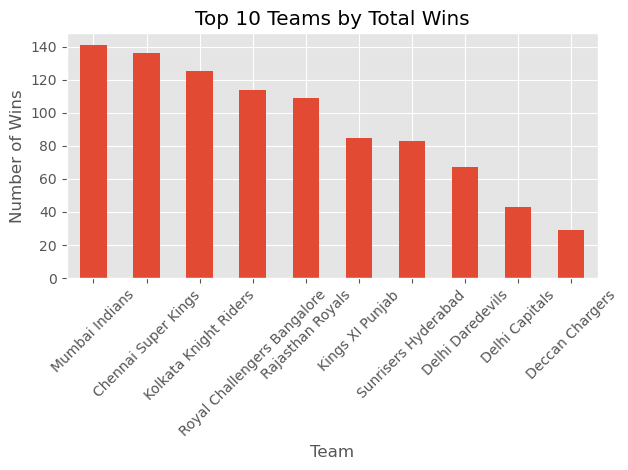

In [81]:
wins_by_team.plot(kind="bar")

plt.title("Top 10 Teams by Total Wins")
plt.xlabel("Team")
plt.ylabel("Number of Wins")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [83]:
wins_by_team

Match_Winner
Mumbai Indians                 141
Chennai Super Kings            136
Kolkata Knight Riders          125
Royal Challengers Bangalore    114
Rajasthan Royals               109
Kings XI Punjab                 85
Sunrisers Hyderabad             83
Delhi Daredevils                67
Delhi Capitals                  43
Deccan Chargers                 29
Name: Match_ID, dtype: int64

In [85]:
win_percentage = (
    wins_by_team / matches_by_team * 100
).sort_values(ascending=False)

win_percentage

Chennai Super Kings                                  NaN
Chennai Super Kings vs Deccan Chargers               NaN
Chennai Super Kings vs Delhi Capitals                NaN
Chennai Super Kings vs Delhi Daredevils              NaN
Chennai Super Kings vs Gujarat Titans                NaN
                                                      ..
Sunrisers Hyderabad vs Rajasthan Royals              NaN
Sunrisers Hyderabad vs Rising Pune Supergiant        NaN
Sunrisers Hyderabad vs Rising Pune Supergiants       NaN
Sunrisers Hyderabad vs Royal Challengers Bangalore   NaN
Sunrisers Hyderabad vs Royal Challengers Bengaluru   NaN
Name: Match_ID, Length: 221, dtype: float64

In [87]:
team_performance["Team1"] = team_performance["Teams"].str.split(" vs ").str[0]

team_performance["Team2"] = team_performance["Teams"].str.split(" vs ").str[1]

In [89]:
team1_matches = team_performance["Team1"].value_counts()

team2_matches = team_performance["Team2"].value_counts()

matches_by_team = team1_matches.add(team2_matches, fill_value=0)

matches_by_team

Chennai Super Kings            234
Deccan Chargers                 75
Delhi Capitals                  88
Delhi Daredevils               161
Gujarat Lions                   30
Gujarat Titans                  43
Kings XI Punjab                190
Kochi Tuskers Kerala            14
Kolkata Knight Riders          246
Lucknow Super Giants            40
Mumbai Indians                 257
Pune Warriors                   46
Punjab Kings                    52
Rajasthan Royals               215
Rising Pune Supergiant          16
Rising Pune Supergiants         14
Royal Challengers Bangalore    240
Royal Challengers Bengaluru     10
Sunrisers Hyderabad            175
Name: count, dtype: int64

In [91]:
wins_by_team = (
    team_performance
    .groupby("Match_Winner")["Match_ID"]
    .count()
)

wins_by_team

Match_Winner
Chennai Super Kings            136
Deccan Chargers                 29
Delhi Capitals                  43
Delhi Daredevils                67
Draw/No Result                  19
Gujarat Lions                   13
Gujarat Titans                  27
Kings XI Punjab                 85
Kochi Tuskers Kerala             6
Kolkata Knight Riders          125
Lucknow Super Giants            23
Mumbai Indians                 141
Pune Warriors                   12
Punjab Kings                    23
Rajasthan Royals               109
Rising Pune Supergiant          10
Rising Pune Supergiants          5
Royal Challengers Bangalore    114
Royal Challengers Bengaluru      3
Sunrisers Hyderabad             83
Name: Match_ID, dtype: int64

In [93]:
win_percentage = (
    wins_by_team / matches_by_team * 100
).sort_values(ascending=False)

win_percentage

Gujarat Titans                 62.790698
Rising Pune Supergiant         62.500000
Chennai Super Kings            58.119658
Lucknow Super Giants           57.500000
Mumbai Indians                 54.863813
Kolkata Knight Riders          50.813008
Rajasthan Royals               50.697674
Delhi Capitals                 48.863636
Royal Challengers Bangalore    47.500000
Sunrisers Hyderabad            47.428571
Kings XI Punjab                44.736842
Punjab Kings                   44.230769
Gujarat Lions                  43.333333
Kochi Tuskers Kerala           42.857143
Delhi Daredevils               41.614907
Deccan Chargers                38.666667
Rising Pune Supergiants        35.714286
Royal Challengers Bengaluru    30.000000
Pune Warriors                  26.086957
Draw/No Result                       NaN
dtype: float64

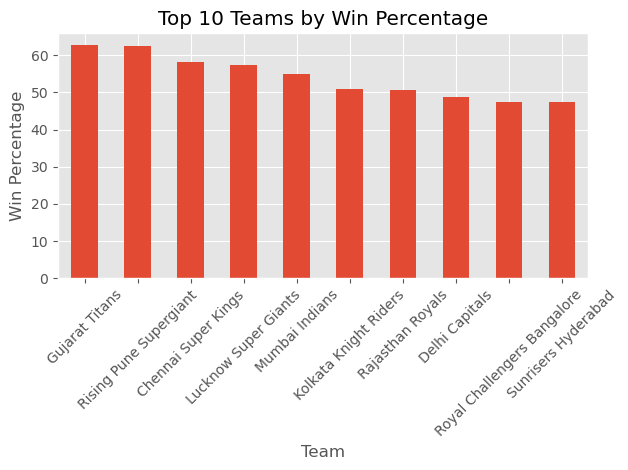

In [95]:
top_win_percentage = win_percentage.head(10)

top_win_percentage.plot(kind="bar")

plt.title("Top 10 Teams by Win Percentage")
plt.xlabel("Team")
plt.ylabel("Win Percentage")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Insight:

The chart shows the top 10 IPL teams based on win percentage.
Teams with higher win percentages demonstrate consistent performance
and competitive strength across multiple seasons.

In [98]:
matches_by_team.head()

Chennai Super Kings    234
Deccan Chargers         75
Delhi Capitals          88
Delhi Daredevils       161
Gujarat Lions           30
Name: count, dtype: int64

In [100]:
win_percentage.head()

Gujarat Titans            62.790698
Rising Pune Supergiant    62.500000
Chennai Super Kings       58.119658
Lucknow Super Giants      57.500000
Mumbai Indians            54.863813
dtype: float64

In [102]:
toss_match_win = team_performance[
    team_performance["Toss_Winner"] ==
    team_performance["Match_Winner"]
]

In [104]:
toss_win_percentage = (
    len(toss_match_win) /
    len(team_performance)
) * 100

toss_win_percentage

50.698974836905876

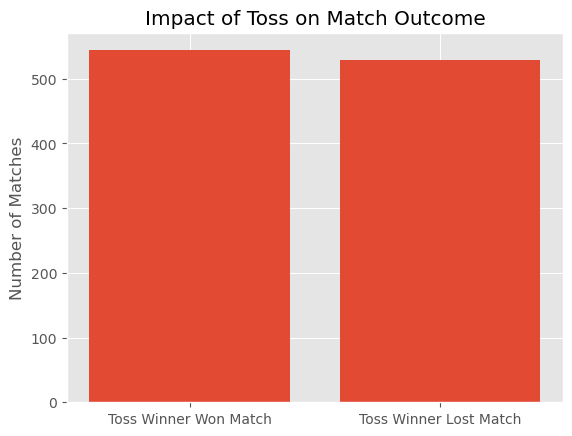

In [106]:
toss_result = [
    len(toss_match_win),
    len(team_performance) - len(toss_match_win)
]

labels = [
    "Toss Winner Won Match",
    "Toss Winner Lost Match"
]

plt.bar(labels, toss_result)

plt.title("Impact of Toss on Match Outcome")
plt.ylabel("Number of Matches")

plt.show()

Insight:

The analysis shows the relationship between winning the toss and winning the match.
A higher percentage indicates that toss decisions can influence match outcomes,
highlighting the strategic importance of the toss in cricket matches.

In [109]:
toss_win_percentage

50.698974836905876

In [111]:
runs_per_match = (
    ball_by_ball
    .groupby("Match id")["runs_scored"]
    .sum()
    .sort_values(ascending=False)
)

runs_per_match.head(10)

Match id
1426268    520
1426280    504
1422126    493
1426281    479
1426273    452
419137     448
1136604    447
1082641    435
1216527    431
1426278    431
Name: runs_scored, dtype: int64

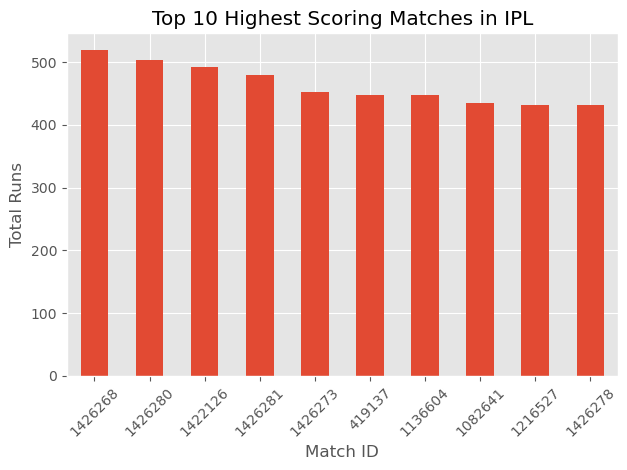

In [113]:
top_matches = runs_per_match.head(10)

top_matches.plot(kind="bar")

plt.title("Top 10 Highest Scoring Matches in IPL")
plt.xlabel("Match ID")
plt.ylabel("Total Runs")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Insight:

The chart highlights the top 10 highest scoring matches in IPL history.
These matches demonstrate high offensive performance and aggressive batting strategies.
Identifying high-scoring matches helps analyze scoring trends and match dynamics.

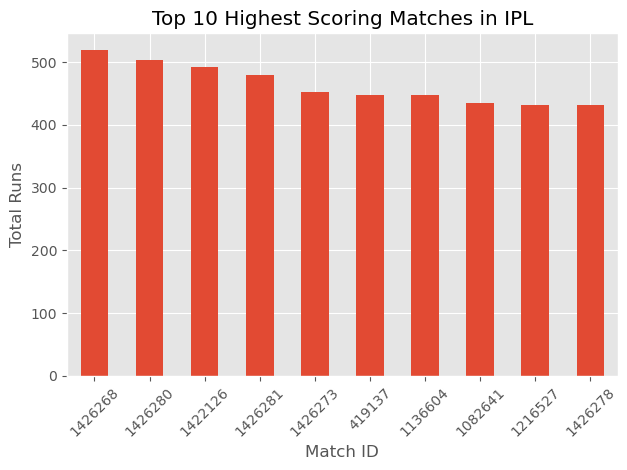

In [116]:
runs_per_match = (
    ball_by_ball
    .groupby("Match id")["runs_scored"]
    .sum()
    .sort_values(ascending=False)
)

top_matches = runs_per_match.head(10)

top_matches.plot(kind="bar")

plt.title("Top 10 Highest Scoring Matches in IPL")
plt.xlabel("Match ID")
plt.ylabel("Total Runs")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Insight:

The chart shows the top 10 highest scoring matches in IPL history.
These matches reflect aggressive batting and high run-scoring performance.

In [119]:
average_runs = (
    ball_by_ball
    .groupby("Match id")["runs_scored"]
    .sum()
    .mean()
)

average_runs

300.77912395153777

Insight:

The average runs per match indicate the general scoring level in IPL matches.
This metric helps understand overall match competitiveness and scoring trends.

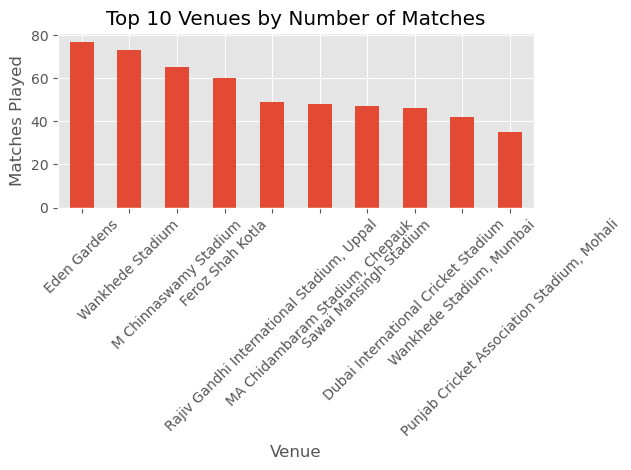

In [122]:
venue_runs = (
    team_performance
    .groupby("Venue")["Match_ID"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

venue_runs.plot(kind="bar")

plt.title("Top 10 Venues by Number of Matches")
plt.xlabel("Venue")
plt.ylabel("Matches Played")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Insight:

The chart shows the top venues hosting the highest number of IPL matches.
These venues are key locations for major matches and tournaments.

Conclusion:

This project analyzed IPL match data to generate insights about player performance,
team performance, match trends, and venue statistics using Python.

Key findings include:

• Identification of top-performing batsmen and bowlers
• Analysis of match and scoring trends across seasons
• Evaluation of team performance using win percentage
• Assessment of toss impact on match outcomes
• Identification of highest scoring matches and key venues

This project demonstrates practical skills in data cleaning, aggregation,
data visualization, and exploratory data analysis using Python.